# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| Æ | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Ø | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Å | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| Q | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



---

## Preamble

In [ ]:
# Relevant imports for the project
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

party_mapping = {
    "Socialdemokratiet": "A",
    "Radikale Venstre": "B",
    "Det Konservative Folkeparti": "C",
    "Nye Borgerlige": "D",
    "Socialistisk Folkeparti": "F",
    "Liberal Alliance": "I",
    "Kristendemokraterne": "K",
    "Moderaterne": "M",
    "Dansk Folkeparti": "O",
    "Danmarksdemokraterne": "Æ",
    "Venstre": "V",
    "Enhedslisten": "Ø",
    "Alternativet": "Å",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "Q"
}

## Loading & Inspecting Data

In [ ]:
df = alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')

### DR Questions

Inspecting the questions from the DR television network immediately revealed that *Info* and *QuestionListData* columns both contain *NaN* values. This could pose a problem in further use of data so we would need to investigate the total amount of missing data and either delete rows with *NaN* values or the columns as a whole. However, considering the fact there the number of questions is low (25), removing the columns would be a more propriete approach.

In [ ]:
drq.head()

: 

In [ ]:

drq.shape

### DR Answers

Initially, we wanted to understand the way, the answers are stored within the dataset. 

As seen below, the DR television network stores the information about the candidate in a form of their name, name of the party they belong to, and answers to each question based on the *ID*.

In [125]:
display(drdata.columns)

Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti'],
      dtype='object')

In [ ]:
drdata.head()

,530,531,533,534,535,537,538,540,541,543,...,552,553,555,556,557,559,561,563,navn,parti
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,-2,2,2,1,2,2,-2,Lars Philipsen Prahm,Moderaterne
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,1,1,-1,-2,1,2,1,2,Karsten Hønge,Socialistisk Folkeparti
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,2,-1,-2,-1,1,2,2,2,Martin Kelleher-Petersen,Alternativet
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,1,2,-2,2,2,2,2,Nicklas Gjedsig Larsen,Alternativet
4,1,1,-2,2,-2,1,-2,1,2,-2,...,2,-2,-2,-1,1,-2,-1,-2,Tom Gillesberg,Løsgænger


### TV2 Questions

The questions of TV2 were formed in slightly different way. The...

In [ ]:
tv2q.head()

: 

### TV2 Responses

Compared to the DR channel, TV2 stored an additional information about each cadidate. These information being the region they reside at, and their age.

In [ ]:
display(tv2data.columns)

In [131]:
tv2data.head()

,1a,1b,2a,2b,3a,3b,4a,4b,5a,5b,...,10a,10b,11a,11b,12a,12b,parti,navn,storkreds,alder
0,0,1,1,1,1,-1,0,1,0,0,...,0,2,-1,2,0,0,Venstre,Birthe Tindbæk Bredo,Bornholms Storkreds,63
1,-1,1,0,-1,2,-2,-1,-1,-2,1,...,1,-1,-1,2,1,-1,Venstre,Julie Pauch Nymark,Bornholms Storkreds,27
2,-2,0,0,1,1,-1,0,1,-1,1,...,1,1,-2,2,1,1,Venstre,Peter Juel-Jensen,Bornholms Storkreds,56
3,-2,-1,2,2,2,-2,0,-1,-2,1,...,1,-1,-2,2,2,-2,Dansk Folkeparti,Mette Sode Hansen,Bornholms Storkreds,42
4,-2,-1,1,1,2,-2,1,0,-1,1,...,2,1,-1,2,0,1,Dansk Folkeparti,René Danielsson,Bornholms Storkreds,35


### Combined Responses

The *"alldata"* dataset consists of the responses from both TV stations merged together. Such a dataset is useful for overall analysis with less of a depth into understanding of each question or candidate.

In [127]:
display(alldata.columns)


Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a',
       '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a',
       '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds',
       'alder'],
      dtype='object')

In [129]:
alldata.head()


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
5,2,1,-2,-2,-1,-1,-1,1,1,-1,...,-1,0,1,1,-1,2,2,-2,Københavns Storkreds,48


### Results of elected candidates

If needed, this dataset could be removed and replaced by inserting a new column into the *"alldata"* with either 1 as elected or 0 for non-elected candidates.

In [155]:
electeddata.head()

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
1,2,2,-2,-2,-2,-2,2,2,2,-2,...,-2,0,-2,2,1,1,0,-2,Østjyllands Storkreds,58
2,2,2,-2,-1,-1,-1,1,-2,2,-2,...,-2,0,-1,2,0,-2,-1,1,Østjyllands Storkreds,30
3,-1,-1,2,-1,2,-1,-2,1,-2,1,...,-1,-1,0,2,-2,2,0,0,Østjyllands Storkreds,53
4,-1,-1,1,-2,2,1,-2,1,-2,1,...,-1,0,1,1,-2,2,1,-1,Østjyllands Storkreds,46


## Preparing Data

We have used the mapping of parties which was shared with us in the beginning of this document to clean the data from any other unexpected party names, or candidates non-affiliated with any party (*Løsgænger*). Additioanlly, we have added the party letters to help with matching of our graphs with the initial election results graph.

Total amount of X rows was removed as result.

In [ ]:
alldata_cleaned = alldata[alldata['parti'].isin(party_mapping.keys())].copy()

alldata_cleaned['parti_letter'] = alldata_cleaned['parti'].map(party_mapping)

print(f'Shape of Original Data: {alldata.shape}')
print(f'Shape of Cleaned Data: {alldata_cleaned.shape}')

## Analysis of Candidate Test 2022 

###  Age of the candidates grouped by parties

As we can see from the analysis below, the *Danmarksdemokraterne* party has the highest age average () of candidates while the *Frie Grønne* places last with the age average of 

Considering the previously given graph of elections results, we cannot clearly find a connection between average age and "success" of a party other than the "youngest" party ended up being second last. 

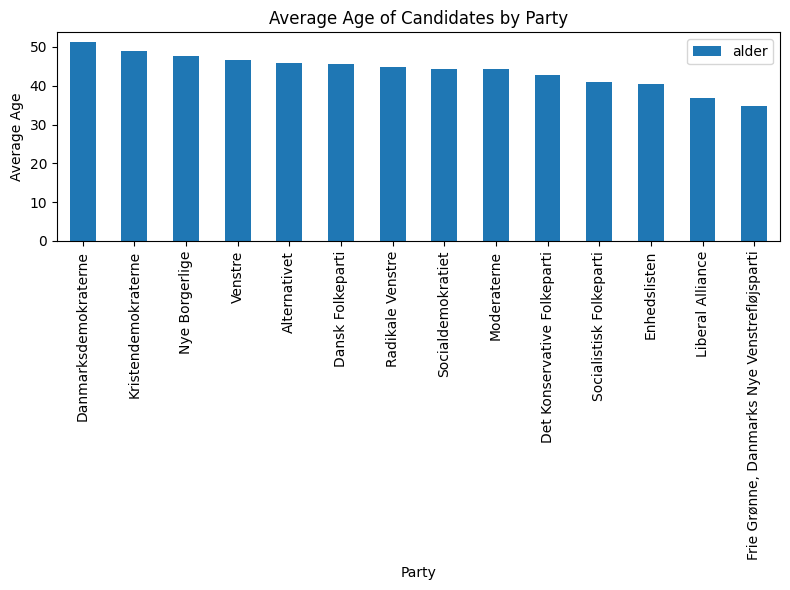

In [ ]:
dfAgeParty = alldata_cleaned[['alder', 'parti']]
grouped_average = dfAgeParty.groupby('parti').mean()
sorted_ages = grouped_average.sort_values('alder', ascending=False)

fig = px.bar(sorted_ages, x='Party', y='Average Age', 
             title='Average Age of Candidates by Party',
             labels={'Average Age': 'Average Age'},
             text='Average Age')

fig.update_traces(texttemplate='%{text}', textposition='outside')
fig.show()

In [ ]:
print(f"Age, Name, and Party of the oldest candidate:{alldata_cleaned.loc[alldata_cleaned['alder'].idxmax()]}")
print(f"Age, Name, and Party of the youngest candidate:{alldata_cleaned.loc[alldata_cleaned['alder'].idxmin()]}")

### An overview of the most "confident" candidates

*NOTE: Those with the highest proportion of "strongly agree" or "strongly disagree" responses are deemed to be the "confident" ones.*

For this analysis, we have decided to use the original dataset since it "clean" version removed candidates without association to any party.

In [ ]:
dfQuestionsWithName = alldata.drop(columns=['storkreds'])

dfQuestionsWithName["confident_answers"] = dfQuestionsWithName.isin([-2,2]).sum(axis=1)

print(dfQuestionsWithName[["navn", "confident_answers", 'age', 'parti']].sort_values("confident_answers", ascending=False).head(10))

                    navn  Confident_Answers
505         Sarah Nørris                 49
88         Søren Vanting                 49
559  Kim Andkjær Doberck                 44
44     Mohamed Abdikarim                 43
152           Rashid Ali                 43
359       Frank Sørensen                 42
151     Elise Bjerkrheim                 42
503          Jan Filbært                 42
284           John Bjerg                 42
437  Lone Vase Langballe                 42


In [ ]:
print(alldata.navn=='Sarah Nørris')

 ### Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.

#### Inter-Party Differences



In [ ]:
inter_party_means = alldata_cleaned.drop(columns=['alder', 'storkreds', 'navn']).groupby('parti').mean()
inter_party_differences = abs(inter_party_means - inter_party_means.mean())

plt.figure(figsize=(12, 6))
sns.heatmap(inter_party_differences, cmap='coolwarm')

plt.show()

,530,531,533,534,535,537,538,540,541,543,...,8a,8b,9a,9b,10a,10b,11a,11b,12a,12b
parti,,,,,,,,,,,,,,,,,,,,,
Alternativet,1.452595,1.356427,1.356726,0.772344,1.644645,1.448905,0.365789,0.117386,1.419517,1.509975,...,0.168482,0.562415,1.164874,0.194355,0.650365,0.590537,1.015785,0.257599,0.169854,0.266731
Danmarksdemokraterne,1.265840,1.156280,2.052310,0.075578,0.888231,0.382075,0.782658,0.653086,1.648656,0.895834,...,0.100174,0.157816,0.880305,0.672527,0.417808,1.479605,1.121368,1.141756,0.175904,0.702208
Dansk Folkeparti,0.999431,0.859534,2.089817,2.701612,0.682494,0.192886,0.468813,0.333726,1.178717,0.433065,...,0.120583,0.082118,1.129064,0.275947,0.417256,1.009666,0.842272,1.045783,0.153936,0.288967
Det Konservative Folkeparti,1.264737,1.655452,1.487776,0.665735,0.947800,1.601049,0.897385,1.262297,0.984839,1.320820,...,0.042683,0.296404,0.812738,0.265743,0.968276,2.051559,0.954517,1.055987,0.102915,0.108992
Enhedslisten,1.531457,2.086963,1.380123,1.453957,2.530688,1.685492,1.501126,2.198265,1.905398,1.860923,...,0.275850,0.125968,1.511586,0.313959,1.541652,1.466092,1.554308,1.912298,1.216445,0.513019


In [ ]:
print('Parties with most inter-party differences')
variance_per_party = inter_party_differences.sum(axis=1)
variance_per_party.head()

#### Intra-Party Differences



In [ ]:
intra_party_variance = alldata_cleaned.drop(columns=['alder', 'storkreds', 'navn']).groupby('parti').var()

plt.figure(figsize=(12, 6))
sns.heatmap(intra_party_variance, cmap='coolwarm')

plt.show()

In [ ]:
print('Parties with most internal differences')
variance_per_party = intra_party_variance.sum(axis=1)
variance_per_party.head()

### Classification models to predict candidates' party affiliations. 
Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

In [153]:
X = df.drop(columns=['navn', 'parti', 'storkreds', 'alder'])
y = df['parti']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Candidates that do not belong to a party

#label encoder???


### Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

                                             precision    recall  f1-score   support

                               Alternativet       0.44      0.31      0.36        13
                       Danmarksdemokraterne       0.92      0.86      0.89        14
                           Dansk Folkeparti       0.88      0.70      0.78        10
                Det Konservative Folkeparti       0.62      0.72      0.67        18
                               Enhedslisten       0.83      0.91      0.87        11
Frie Grønne, Danmarks Nye Venstrefløjsparti       1.00      0.67      0.80         6
                        Kristendemokraterne       0.60      0.38      0.46         8
                           Liberal Alliance       0.64      0.53      0.58        17
                                  Løsgænger       0.00      0.00      0.00         0
                                Moderaterne       0.33      1.00      0.50         2
                             Nye Borgerlige       0.71      0.94

/home/mark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

### Gradient Boosted Tree

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))